# Glioma UGE atlas and cellular states

This notebook reproduces the data-driven results in UniGeneX manuscript **Figure 5B–C**:

- **Figure 5B:** the glioma UGE atlas colored by developmental stage, tumor IDH status, and final cell type;
- **Figure 5C:** ten conserved glioma cellular states identified in UGE space.

Figure 5A is a conceptual workflow schematic and is not generated computationally. This notebook visualizes the released UGE atlas; it does not retrain UniGeneX or recompute the atlas embedding.

## Data contract

The notebook expects a data root containing a `GBM/` directory. Set the root with the `UNIGENEX_DATA_DIR` environment variable. If it is not set, the notebook looks for `./data/GBM` relative to the working directory.

Required input:

| File | Purpose |
|---|---|
| `GBM/UGE_atlas.h5ad` | UGE expression, final annotations, IDH status, and UMAP coordinates |

After downloading and extracting the GBM data release, the relevant tree should be:

```text
<data root>/
└── GBM/
    └── UGE_atlas.h5ad
```

Download `GBM_UGE_atlas_v1.0.0.zip` from the [UniGeneX GBM Zenodo record](https://doi.org/10.5281/zenodo.22566537) and extract it without changing the internal paths. Generated panels are written to `outputs/01_glioma_uge_atlas/` by default. Set `UNIGENEX_OUTPUT_DIR` to use another location.

In [1]:
from importlib.metadata import version
from pathlib import Path
import os
import platform
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

RANDOM_SEED = 0

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
GBM_DATA_DIR = DATA_ROOT / "GBM"

OUTPUT_DIR = Path(
    os.environ.get(
        "UNIGENEX_OUTPUT_DIR",
        Path.cwd() / "outputs" / "01_glioma_uge_atlas",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ATLAS_PATH = GBM_DATA_DIR / "UGE_atlas.h5ad"
if not ATLAS_PATH.is_file():
    raise FileNotFoundError(
        f"Missing GBM atlas: {ATLAS_PATH}\n"
        "Set UNIGENEX_DATA_DIR to the directory that contains GBM/."
    )

sns.set_theme(style="white", context="paper")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.family": "sans-serif",
})

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")

Data root: /path/to/unigenex_data
Output directory: /path/to/unigenex_outputs/01_glioma_uge_atlas


## Load and validate the released atlas

Backed mode keeps the large UGE expression matrix on disk. Only the annotations and two-dimensional UMAP coordinates required for Figure 5B–C are loaded into memory. The validation table checks the atlas dimensions, required annotation columns, embedding coordinates, and release metadata before plotting.

In [2]:
atlas = sc.read_h5ad(ATLAS_PATH, backed="r")

REQUIRED_OBS = [
    "development_stage",
    "idh_status",
    "cell_type",
    "tumor_state",
]
missing_obs = sorted(set(REQUIRED_OBS).difference(atlas.obs.columns))
if missing_obs:
    raise KeyError(f"Atlas is missing required obs columns: {missing_obs}")
if "X_umap" not in atlas.obsm:
    raise KeyError("Atlas is missing obsm['X_umap'].")
if not atlas.obs_names.is_unique:
    raise ValueError("Atlas observation names must be unique.")

labels = atlas.obs[REQUIRED_OBS].copy()
umap = np.asarray(atlas.obsm["X_umap"])
if umap.shape != (atlas.n_obs, 2):
    raise ValueError(
        f"Expected X_umap shape ({atlas.n_obs}, 2), observed {umap.shape}."
    )

summary = pd.Series({
    "Atlas cells": atlas.n_obs,
    "UGE genes": atlas.n_vars,
    "Developmental stages": labels["development_stage"].nunique(),
    "Cells with IDH status": labels["idh_status"].notna().sum(),
    "Final cell types": labels["cell_type"].nunique(),
    "Glioma cells with a tumor state": labels["tumor_state"].notna().sum(),
}, name="Value").to_frame()
display(summary.style.format(thousands=","))
print(atlas)

,Value
Atlas cells,"800,000"
UGE genes,"2,640"
Developmental stages,9
Cells with IDH status,"241,215"
Final cell types,31
Glioma cells with a tumor state,"93,384"


AnnData object with n_obs × n_vars = 800000 × 2640 backed at '/path/to/unigenex_data/GBM/UGE_atlas.h5ad'
    obs: 'cell_id', 'dataset_cell_id', 'dataset_idx', 'dataset', 'donor_id', 'development_stage', 'idh_status', 'cell_type', 'tumor_state', 'cell_state'
    uns: 'neighbors', 'pca', 'umap', 'unigenex_release'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


## Figure 5B — Joint developmental and glioma UGE atlas

The left manuscript panels show the atlas by developmental stage and IDH status. Cells without a tumor IDH annotation remain light gray in the IDH panel. The right panel shows the final cell types grouped into glial, progenitor, neuronal, and stromal compartments.

The plotting order is shuffled with a fixed seed to avoid systematically hiding one category behind another while keeping the result reproducible.

In [3]:
DEVELOPMENT_STAGE_COLORS = {
    "1st trimester": "#5B529E",
    "2nd trimester": "#4F88B7",
    "3rd trimester": "#FBFDBF",
    "Infant": "#F4BF7B",
    "Toddlerhood": "#EC9D62",
    "Child": "#D25D50",
    "Adolescent": "#C14851",
    "Adult": "#921D43",
    "Cells from tumor samples": "#808080",
}

IDH_STATUS_COLORS = {
    "Mutant": "#5F81D5",
    "WT": "#CF4027",
}

CELL_TYPE_GROUPS = {
    "Glioma": ["Glioma"],
    "Glial Cells": ["Astro", "Glioblasts", "OPC", "Oligo", "TA-Oligo"],
    "Progenitor Associated States": [
        "Progenitor", "RG", "Dividing", "Mesenchymal",
    ],
    "Interneurons (IN)": [
        "Immature IN", "Immature IN Dividing", "Non-cortical IN",
        "Immature IN - CGE", "Immature IN - MGE", "VIP", "SST",
        "PV", "LAMP5",
    ],
    "Excitatory Neurons (EXN)": ["EXN dev", "L2-3", "L4", "L5-6"],
    "Stroma": [
        "TA-Mg", "TAM-FTL", "TAM-Phag", "TA-Mo-Native",
        "B Cells", "Lympoid", "Vascular", "Microglial cell",
    ],
}

CELL_TYPE_COLORS = {
    "Glioma": "#782E33",
    "Astro": "#464494",
    "Glioblasts": "#B99CC9",
    "OPC": "#B3B0D4",
    "Oligo": "#CFA1D3",
    "TA-Oligo": "#DBC3DC",
    "Progenitor": "#2E4866",
    "RG": "#2C662C",
    "Dividing": "#569B56",
    "Mesenchymal": "#81C181",
    "Immature IN": "#964F1B",
    "Immature IN Dividing": "#A86838",
    "Non-cortical IN": "#B77B4E",
    "Immature IN - CGE": "#C68F66",
    "Immature IN - MGE": "#CE9C76",
    "VIP": "#DDAC87",
    "SST": "#EFC4A3",
    "PV": "#F7D5BC",
    "LAMP5": "#FCC6B1",
    "EXN dev": "#A7DCE8",
    "L2-3": "#4F728E",
    "L4": "#80B5C1",
    "L5-6": "#94E0DE",
    "TA-Mg": "#B0C4DE",
    "TAM-FTL": "#B0A8B9",
    "TAM-Phag": "#C5BFA5",
    "TA-Mo-Native": "#8FBC8F",
    "B Cells": "#F593CB",
    "Lympoid": "#C89C9B",
    "Vascular": "#E5AEAA",
    "Microglial cell": "#F9CBDA",
}

TUMOR_STATE_COLORS = {
    "Classical-Cycling": "#C69FE8",
    "Classical-EGFR": "#9D47E8",
    "IDH-mut AC-like": "#2B5680",
    "IDH-mut Oligo-like": "#559E46",
    "IDH-mut STEM-like": "#DBF0AA",
    "MES-AC": "#AF6F7B",
    "MES-Hyp": "#AF303C",
    "MES-Inflammatory": "#782E33",
    "STEM-Cycling": "#BCCD91",
    "STEM-like": "#486F65",
}

In [4]:
def validate_categories(values, palette, label):
    """Fail clearly if a release contains labels without assigned colors."""
    observed = set(values.dropna().astype(str))
    unexpected = sorted(observed.difference(palette))
    if unexpected:
        raise ValueError(f"Unexpected {label} labels: {unexpected}")
    missing = sorted(set(palette).difference(observed))
    if missing:
        warnings.warn(f"Expected {label} labels not present: {missing}")


def categorical_umap(
    ax,
    coordinates,
    values,
    palette,
    title,
    *,
    seed=RANDOM_SEED,
    point_size=0.35,
    background_color="#E0E0E0",
    legend_columns=1,
    legend_bbox=(0, 1),
):
    """Draw a deterministic, rasterized categorical UMAP."""
    values = values.astype("string").fillna("<missing>").to_numpy()
    colors = np.full(values.size, background_color, dtype=object)
    for category, color in palette.items():
        colors[values == category] = color

    draw_order = np.random.default_rng(seed).permutation(values.size)
    ax.scatter(
        coordinates[draw_order, 0],
        coordinates[draw_order, 1],
        c=colors[draw_order],
        s=point_size,
        linewidths=0,
        alpha=0.85,
        rasterized=True,
    )

    present = set(values)
    handles = [
        Line2D(
            [0], [0], marker="o", linestyle="", label=category,
            markerfacecolor=color, markeredgewidth=0, markersize=5,
        )
        for category, color in palette.items()
        if category in present
    ]
    ax.legend(
        handles=handles, frameon=False, fontsize=8, ncol=legend_columns,
        loc="upper left", bbox_to_anchor=legend_bbox, markerscale=1.2,
    )
    ax.set_title(title, loc="left", fontweight="bold")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_axis_off()
    return ax


def add_grouped_legend(ax, groups, palette):
    """Add the grouped cell-type legend used in Figure 5B."""
    handles = []
    headings = set(groups)
    for heading, categories in groups.items():
        handles.append(Line2D([], [], linestyle="", label=heading))
        handles.extend(
            Line2D(
                [0], [0], marker="o", linestyle="", label=category,
                markerfacecolor=palette[category], markeredgewidth=0,
                markersize=5,
            )
            for category in categories
        )
    legend = ax.legend(
        handles=handles, frameon=False, fontsize=7, ncol=2,
        loc="upper left", bbox_to_anchor=(1.01, 1),
        handlelength=0.8, handletextpad=0.4, columnspacing=0.8,
    )
    for text in legend.get_texts():
        if text.get_text() in headings:
            text.set_fontweight("bold")
    return legend

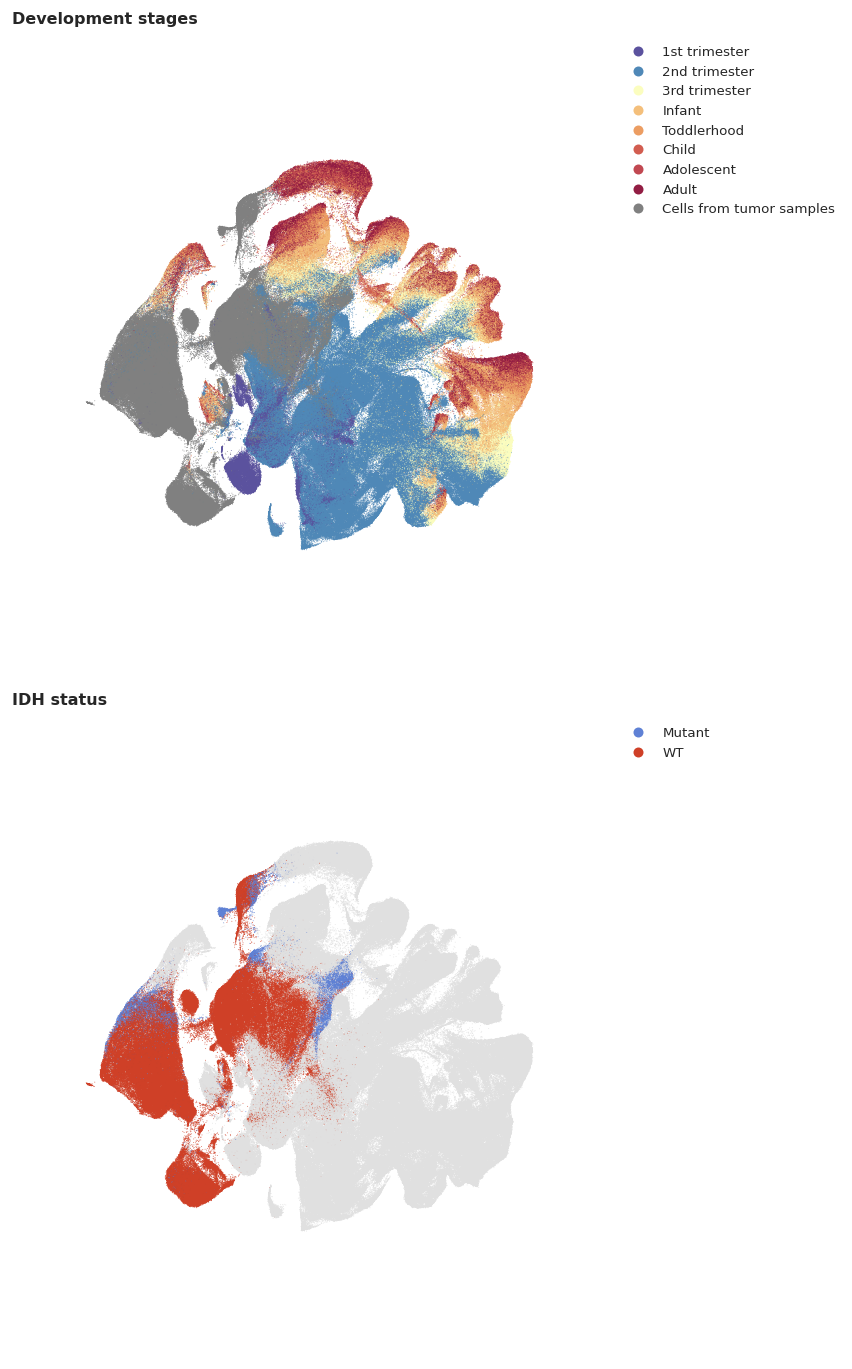

In [5]:
validate_categories(
    labels["development_stage"],
    DEVELOPMENT_STAGE_COLORS,
    "development-stage",
)
validate_categories(labels["idh_status"], IDH_STATUS_COLORS, "IDH-status")

fig, axes = plt.subplots(2, 1, figsize=(7.2, 11.5))
categorical_umap(
    axes[0], umap, labels["development_stage"], DEVELOPMENT_STAGE_COLORS,
    "Development stages", seed=RANDOM_SEED, point_size=0.30,
    legend_columns=1, legend_bbox=(1.01, 1),
)
categorical_umap(
    axes[1], umap, labels["idh_status"], IDH_STATUS_COLORS,
    "IDH status", seed=RANDOM_SEED + 1, point_size=0.30,
    legend_bbox=(1.01, 1),
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "Figure5B_development_stage_and_IDH.png",
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

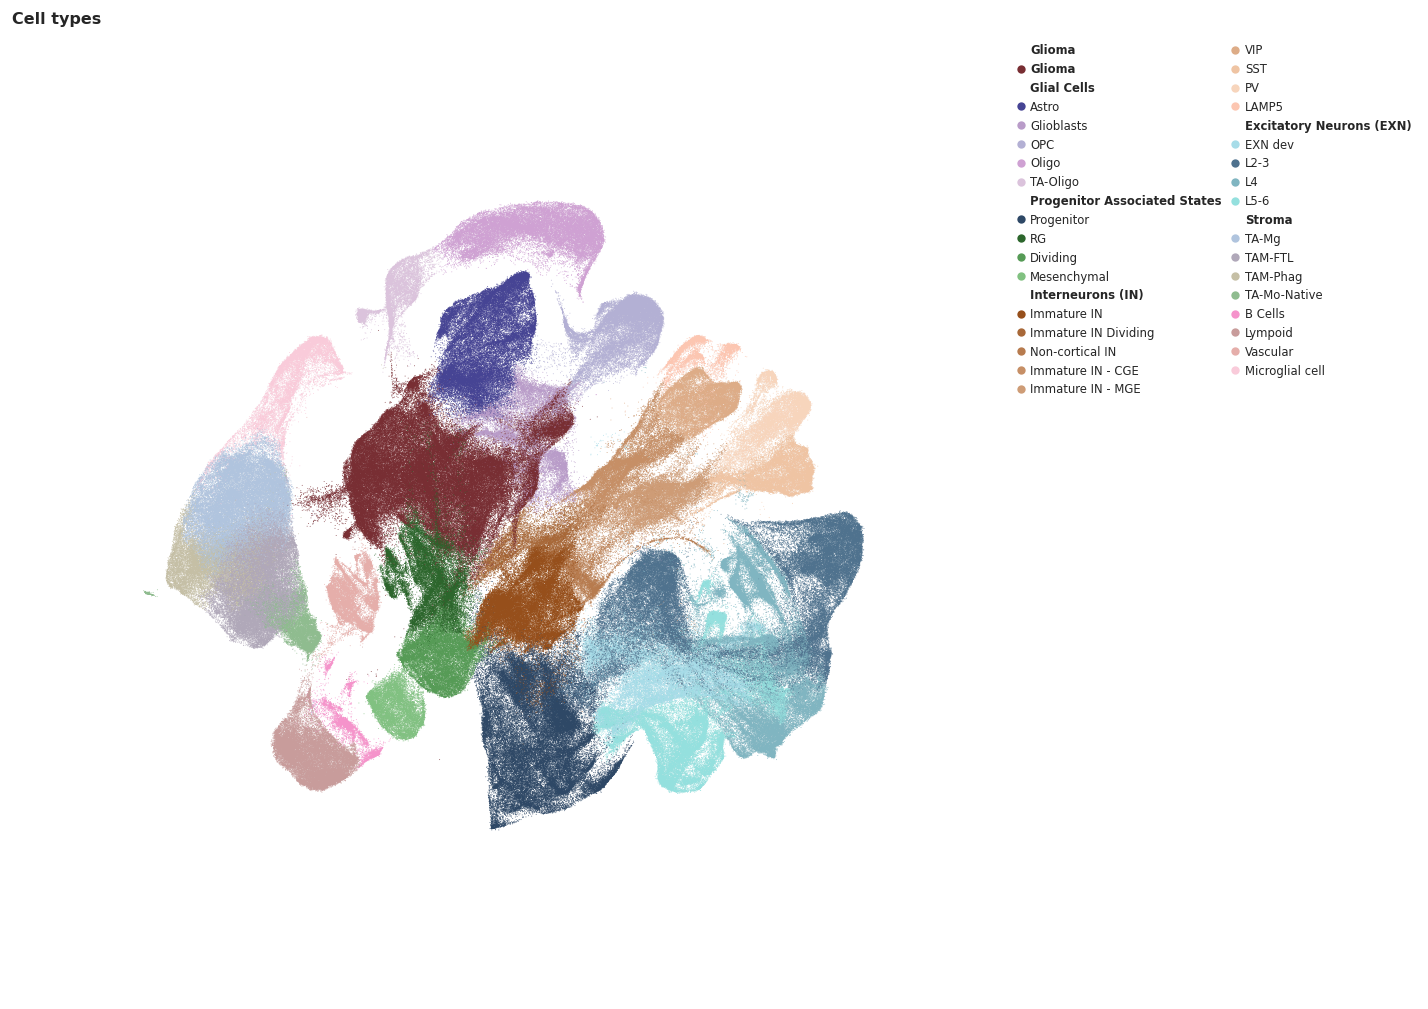

Plotted 764,239 cells with final cell-type labels.


In [6]:
validate_categories(labels["cell_type"], CELL_TYPE_COLORS, "cell-type")
cell_type_mask = labels["cell_type"].notna().to_numpy()

fig, ax = plt.subplots(figsize=(12, 8.5))
categorical_umap(
    ax,
    umap[cell_type_mask],
    labels.loc[cell_type_mask, "cell_type"],
    CELL_TYPE_COLORS,
    "Cell types",
    seed=RANDOM_SEED + 2,
    point_size=0.32,
)
ax.get_legend().remove()
add_grouped_legend(ax, CELL_TYPE_GROUPS, CELL_TYPE_COLORS)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "Figure5B_cell_types.png", bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Plotted {cell_type_mask.sum():,} cells with final cell-type labels.")

## Figure 5C — Conserved glioma cellular states

Glioma cells are categorized into ten states: three IDH-mutant states and seven IDH-wild-type states. To match the manuscript plotting workflow, cells above the 99th percentile of mean 30-nearest-neighbor distance in UMAP space are omitted as visualization outliers. This affects plotting only; it does not alter the released atlas or its annotations.

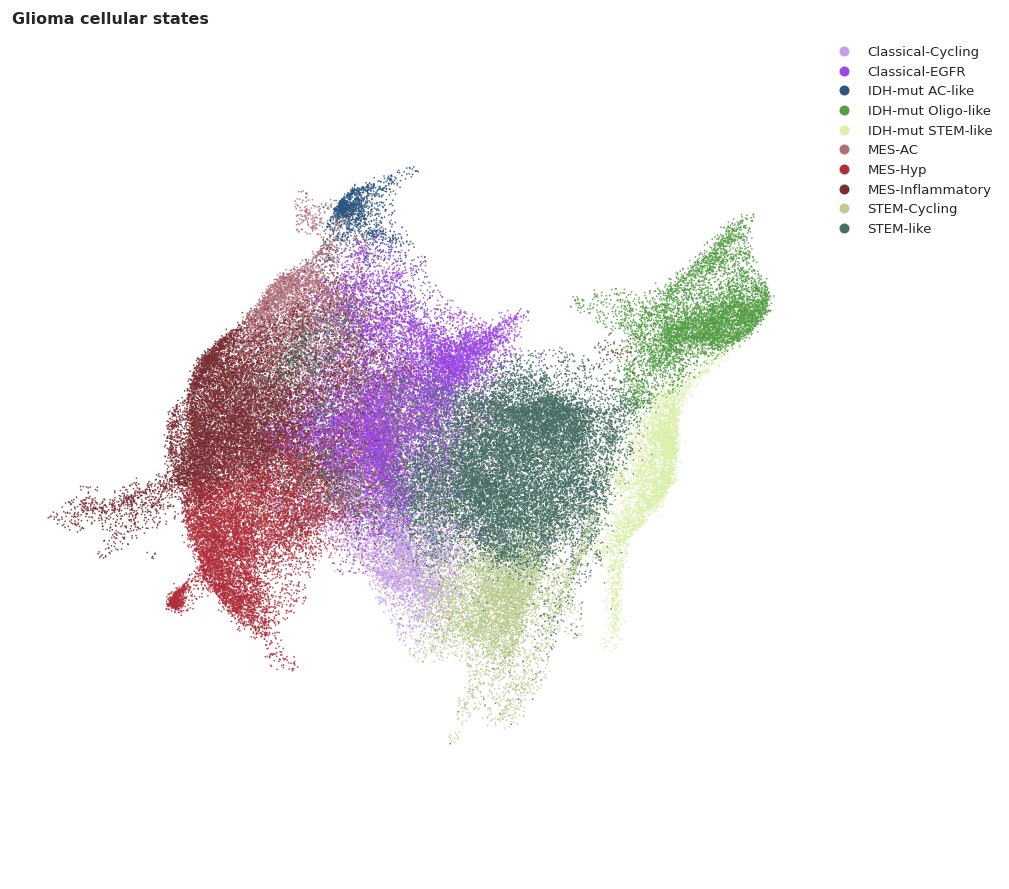

,n_cells
tumor_state,
Classical-Cycling,"4,132"
Classical-EGFR,"13,829"
IDH-mut AC-like,"1,562"
IDH-mut Oligo-like,"6,468"
IDH-mut STEM-like,"4,351"
MES-AC,"6,169"
MES-Hyp,"11,938"
MES-Inflammatory,"15,209"
STEM-Cycling,"6,499"


Plotted 92,450 of 93,384 tumor cells; omitted 934 visualization outliers.


In [7]:
def identify_umap_outliers(coordinates, n_neighbors=30, quantile=0.99):
    """Match the local-density outlier rule used for manuscript Figure 5C."""
    if coordinates.shape[0] < n_neighbors:
        raise ValueError("Too few cells for the requested neighbor count.")
    neighbors = NearestNeighbors(n_neighbors=n_neighbors).fit(coordinates)
    distances, _ = neighbors.kneighbors(coordinates)
    mean_distances = distances.mean(axis=1)
    threshold = np.quantile(mean_distances, quantile)
    return mean_distances > threshold


validate_categories(labels["tumor_state"], TUMOR_STATE_COLORS, "tumor-state")
tumor_mask = labels["tumor_state"].notna().to_numpy()
tumor_umap = umap[tumor_mask]
tumor_states = labels.loc[tumor_mask, "tumor_state"]
outlier_mask = identify_umap_outliers(tumor_umap)

fig, ax = plt.subplots(figsize=(8.5, 7.5))
categorical_umap(
    ax,
    tumor_umap[~outlier_mask],
    tumor_states.loc[~outlier_mask],
    TUMOR_STATE_COLORS,
    "Glioma cellular states",
    seed=RANDOM_SEED + 3,
    point_size=1.1,
    legend_bbox=(1.01, 1),
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "Figure5C_tumor_states.png", bbox_inches="tight")
plt.show()
plt.close(fig)

state_counts = (
    tumor_states.value_counts()
    .reindex(TUMOR_STATE_COLORS)
    .rename("n_cells")
    .to_frame()
)
state_counts.to_csv(OUTPUT_DIR / "Figure5C_tumor_state_counts.csv")
display(state_counts.style.format(thousands=","))
print(
    f"Plotted {(~outlier_mask).sum():,} of {tumor_mask.sum():,} tumor cells; "
    f"omitted {outlier_mask.sum():,} visualization outliers."
)

## Interpretation and next step

The shared UGE coordinates place healthy developmental brain populations and glioma-derived cells in a common representation. The developmental-stage and cell-type panels summarize the atlas context, while Figure 5C focuses on heterogeneity among annotated glioma cells. These views are descriptive and should not, by themselves, be interpreted as developmental lineage or causal relationships.

Notebook `02_uge_atlas_guided_visium.ipynb` will use the expression matrix and tumor-state annotations in this same `UGE_atlas.h5ad` to prepare the Cell2location reference signatures for Visium decomposition.

In [8]:
atlas.file.close()

print(f"Python: {platform.python_version()}")
print(f"anndata: {ad.__version__}")
print(f"scanpy: {version('scanpy')}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"matplotlib: {mpl.__version__}")
print(f"Completed outputs: {OUTPUT_DIR}")

Python: 3.10.20
anndata: 0.11.4
scanpy: 1.11.5
pandas: 2.3.3
scikit-learn: 1.7.2
matplotlib: 3.10.8
Completed outputs: /path/to/unigenex_outputs/01_glioma_uge_atlas
